## 2. Missing Values And Coverage

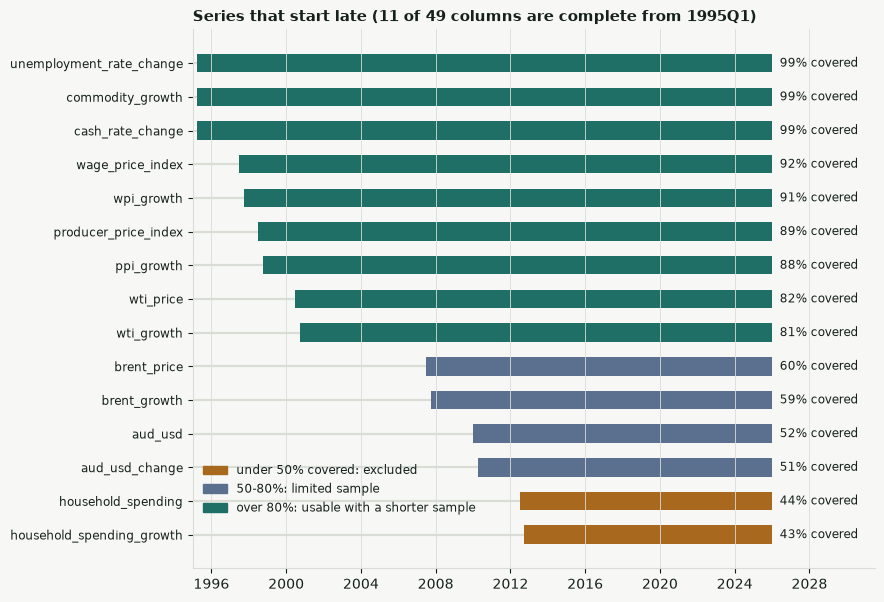

In [3]:
def first_last_non_null_date(frame: pd.DataFrame, column: str) -> tuple[str | None, str | None]:
    mask = frame[column].notna()
    if not mask.any():
        return None, None
    return str(frame.loc[mask, 'quarter_period'].iloc[0]), str(frame.loc[mask, 'quarter_period'].iloc[-1])


def coverage_class(coverage_pct: float) -> str:
    if coverage_pct >= 0.95:
        return 'core_long_sample_candidate'
    if coverage_pct >= 0.80:
        return 'shorter_sample_candidate'
    if coverage_pct >= 0.50:
        return 'limited_sample_candidate'
    return 'exclude_low_coverage'


sample_start = str(df['quarter_period'].min())
coverage_rows = []
for column in df_model.columns:
    if column == 'quarter':
        continue
    first_non_null, last_non_null = first_last_non_null_date(df, column)
    missing_count = int(df[column].isna().sum())
    available_observations = int(df[column].notna().sum())
    missing_pct = missing_count / len(df)
    coverage_pct = available_observations / len(df)
    late_start_reduces_sample = first_non_null not in {None, sample_start}
    substantial_missingness = missing_pct >= MATERIAL_MISSING_THRESHOLD
    coverage_rows.append({
        'variable': column,
        'available_observations': available_observations,
        'non_null_rows': available_observations,
        'missing_count': missing_count,
        'missing_pct': missing_pct,
        'coverage_pct': coverage_pct,
        'start_quarter': sample_start,
        'first_non_null': first_non_null,
        'last_non_null': last_non_null,
        'late_start_reduces_estimation_sample': bool(late_start_reduces_sample),
        'substantial_missingness_warning': bool(substantial_missingness),
        # Backward-compatible name used later in the notebook; this now means
        # genuinely substantial missingness, not merely starting after 1995Q1.
        'material_early_missingness': bool(substantial_missingness),
        'coverage_class': coverage_class(coverage_pct),
    })

coverage = pd.DataFrame(coverage_rows).sort_values(['missing_pct', 'variable'], ascending=[False, True])
with plt.rc_context(BOOK_STYLE):
    late = coverage[(coverage["first_non_null"] != coverage["start_quarter"]) & ~coverage["variable"].str.contains("_lag")].copy()
    late["start"] = pd.PeriodIndex(late["first_non_null"], freq="Q").to_timestamp()
    late["end"] = pd.PeriodIndex(late["last_non_null"], freq="Q").to_timestamp(how="end")
    late = late.sort_values("start", ascending=False).reset_index(drop=True)
    colours = {"exclude_low_coverage": HIGHLIGHT, "limited_sample_candidate": BLUE, "shorter_sample_candidate": ACCENT,
               "core_long_sample_candidate": ACCENT}
    sample_start = pd.Period(coverage["start_quarter"].iloc[0], freq="Q").to_timestamp()
    fig, ax = plt.subplots(figsize=(8.8, 0.36 * len(late) + 1.6))
    for y, r in late.iterrows():
        ax.barh(y, (r["end"] - r["start"]).days, left=r["start"], color=colours.get(r["coverage_class"], MUTED), height=0.55)
        ax.plot([sample_start, r["start"]], [y, y], color=GRID, linewidth=1.6, zorder=0)
        ax.text(r["end"] + pd.Timedelta(days=150), y, f"{r['coverage_pct'] * 100:.0f}% covered", va="center", fontsize=8.5)
    ax.set_yticks(range(len(late)), late["variable"], fontsize=8.8)
    ax.set_xlim(sample_start, pd.Timestamp("2031-06-30"))
    complete = int((coverage["first_non_null"] == coverage["start_quarter"]).sum())
    ax.set_title(f"Series that start late ({complete} of {len(coverage)} columns are complete from {coverage['start_quarter'].iloc[0]})",
                 loc="left", fontsize=11, fontweight="bold")
    from matplotlib.patches import Patch
    ax.legend(handles=[Patch(color=colours[k], label=t) for t, k in [("under 50% covered: excluded", "exclude_low_coverage"),
                                                                    ("50-80%: limited sample", "limited_sample_candidate"),
                                                                    ("over 80%: usable with a shorter sample", "shorter_sample_candidate")]],
              frameon=False, fontsize=8.5, loc="lower left", bbox_to_anchor=(0.0, 0.08))
    ax.grid(axis="y", visible=False)
    plt.show()
pass

**Interpretation.** The worst-coverage predictors — `household_spending_growth`
(43% coverage, doesn't start until 2012Q4), `aud_usd_change` (51%, starts 2010Q2), and
`brent_growth` (59%, starts 2007Q4) — aren't broken data, they're series whose underlying
collection or the project's own retrieval simply doesn't reach back to 1995Q1. The
`coverage_class` column turns this into an explicit modelling decision (`exclude_low_coverage`
vs. `limited_sample_candidate`) rather than a silent one, and it's the reason those same
variables show up later in §6/§7 with much smaller `n_obs` than series like `cpi_qoq` or
`cash_rate` that are complete from the start.